<a href="https://colab.research.google.com/github/CodeMind-s/Final-Year-Research-25-26J-431/blob/Crystallization-Forecasting-model-Development/Prophet_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOADING DATA
✓ Loaded log_data_total.csv with utf-8 encoding
✓ Loaded aggregated_data_total.csv with utf-8 encoding
✓ Loaded production_data_total.csv with utf-8 encoding
✓ Log data: (1095, 16)
✓ Production data: (36, 2)
✓ Aggregated data: (35, 35)
DATA DIAGNOSTICS

1. BASIC STATISTICS:
   Records: 36
   Mean: 60014.37
   Median: 44000.90
   Std Dev: 43605.14
   CV (Coefficient of Variation): 72.7%
   Min: 759.80
   Max: 160741.80

2. OUTLIER ANALYSIS:
   Outliers detected: 1
   Outlier dates: ['2024-03']
   Outlier values: [160741.8]

3. SEASONALITY ANALYSIS:
   Monthly variation: 34108.45
   Highest month: 8 (avg: 129260.80)
   Lowest month: 11 (avg: 20288.20)

4. TREND ANALYSIS:
   Linear trend slope: -615.71 units/month
   R²: 0.0221
   Trend: Decreasing

5. DATA QUALITY:
   Zero values: 0
   Missing values: 0

TRAINING IMPROVED PROPHET MODEL

⚠ Found 1 outliers - capping them

Fitting model...
✓ Model trained

IN-SAMPLE PERFORMANCE
MAE:  12,591.91
RMSE: 18,557.39
R²:   0.8085
MAPE

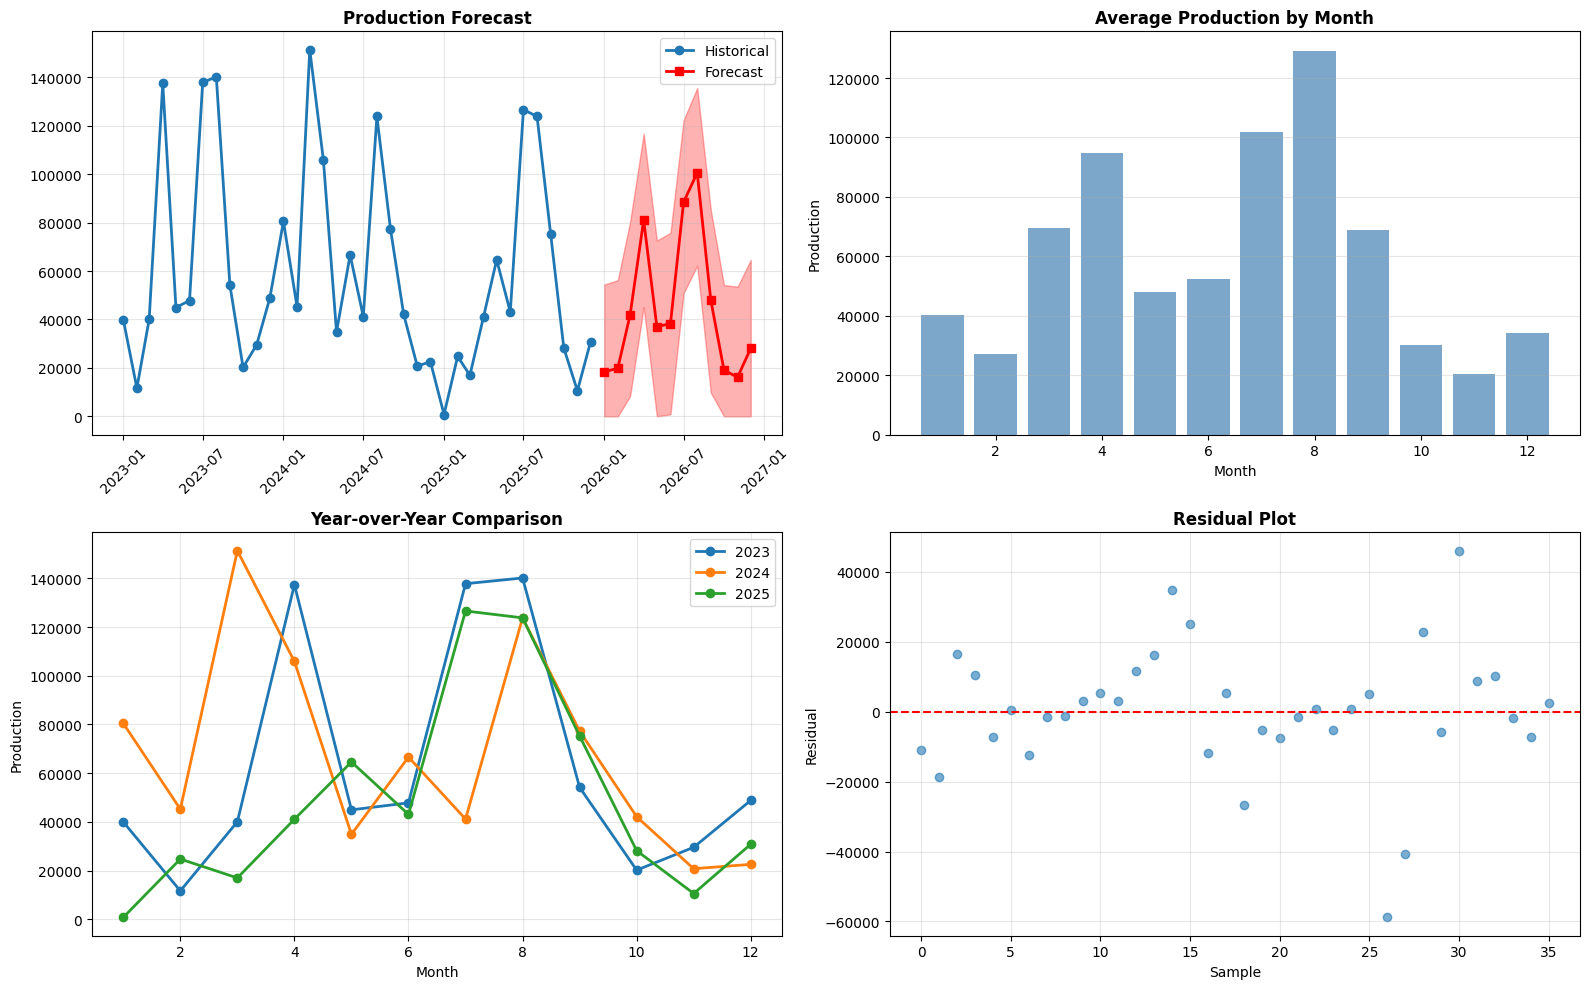


✓ Created folder: prophet_results/
✓ Results saved to prophet_results/improved_forecast.csv
✓ Cleaned data saved to prophet_results/cleaned_data.csv
✓ Model saved to prophet_results/improved_model.pkl


In [8]:
# ============================================================
# IMPROVED PROPHET MODEL WITH DIAGNOSTICS
# ============================================================

import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. DATA DIAGNOSTICS
# ============================================================

def diagnose_data(prod_df):
    """Comprehensive data diagnostics"""
    print("="*60)
    print("DATA DIAGNOSTICS")
    print("="*60)

    prophet_df = prod_df[['month', 'production_volume']].copy()
    prophet_df.columns = ['ds', 'y']

    # Basic statistics
    print("\n1. BASIC STATISTICS:")
    print(f"   Records: {len(prophet_df)}")
    print(f"   Mean: {prophet_df['y'].mean():.2f}")
    print(f"   Median: {prophet_df['y'].median():.2f}")
    print(f"   Std Dev: {prophet_df['y'].std():.2f}")
    print(f"   CV (Coefficient of Variation): {(prophet_df['y'].std() / prophet_df['y'].mean() * 100):.1f}%")
    print(f"   Min: {prophet_df['y'].min():.2f}")
    print(f"   Max: {prophet_df['y'].max():.2f}")

    # Outlier detection
    Q1 = prophet_df['y'].quantile(0.25)
    Q3 = prophet_df['y'].quantile(0.75)
    IQR = Q3 - Q1
    outliers = prophet_df[(prophet_df['y'] < Q1 - 1.5*IQR) | (prophet_df['y'] > Q3 + 1.5*IQR)]

    print(f"\n2. OUTLIER ANALYSIS:")
    print(f"   Outliers detected: {len(outliers)}")
    if len(outliers) > 0:
        print(f"   Outlier dates: {outliers['ds'].dt.strftime('%Y-%m').tolist()}")
        print(f"   Outlier values: {outliers['y'].tolist()}")

    # Seasonality check
    prophet_df['month'] = prophet_df['ds'].dt.month
    monthly_avg = prophet_df.groupby('month')['y'].mean()

    print(f"\n3. SEASONALITY ANALYSIS:")
    print(f"   Monthly variation: {monthly_avg.std():.2f}")
    print(f"   Highest month: {monthly_avg.idxmax()} (avg: {monthly_avg.max():.2f})")
    print(f"   Lowest month: {monthly_avg.idxmin()} (avg: {monthly_avg.min():.2f})")

    # Trend analysis
    from scipy import stats
    x = np.arange(len(prophet_df))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, prophet_df['y'])

    print(f"\n4. TREND ANALYSIS:")
    print(f"   Linear trend slope: {slope:.2f} units/month")
    print(f"   R²: {r_value**2:.4f}")
    print(f"   Trend: {'Increasing' if slope > 0 else 'Decreasing'}")

    # Zero/missing values
    zeros = (prophet_df['y'] == 0).sum()
    print(f"\n5. DATA QUALITY:")
    print(f"   Zero values: {zeros}")
    print(f"   Missing values: {prophet_df['y'].isna().sum()}")

    return prophet_df, outliers

# ============================================================
# 2. IMPROVED PROPHET MODEL
# ============================================================

def train_improved_prophet(prod_df, handle_outliers=True, transform_data=False):
    """
    Improved Prophet with better parameters for small datasets
    """
    print("\n" + "="*60)
    print("TRAINING IMPROVED PROPHET MODEL")
    print("="*60)

    prophet_df = prod_df[['month', 'production_volume']].copy()
    prophet_df.columns = ['ds', 'y']

    # Handle outliers if requested
    if handle_outliers:
        Q1 = prophet_df['y'].quantile(0.25)
        Q3 = prophet_df['y'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_mask = (prophet_df['y'] < lower_bound) | (prophet_df['y'] > upper_bound)
        n_outliers = outliers_mask.sum()

        if n_outliers > 0:
            print(f"\n⚠ Found {n_outliers} outliers - capping them")
            prophet_df.loc[prophet_df['y'] < lower_bound, 'y'] = lower_bound
            prophet_df.loc[prophet_df['y'] > upper_bound, 'y'] = upper_bound

    # Optional: Log transform for high variance data
    original_y = prophet_df['y'].copy()
    if transform_data:
        print("📊 Applying log transformation to stabilize variance")
        prophet_df['y'] = np.log1p(prophet_df['y'])

    # Add seasonal indicators
    prophet_df['is_yala'] = prophet_df['ds'].dt.month.isin([5, 6, 7, 8]).astype(int)
    prophet_df['is_maha'] = prophet_df['ds'].dt.month.isin([11, 12, 1, 2]).astype(int)

    # Optimized Prophet for small datasets
    model = Prophet(
        growth='linear',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.01,  # Reduced for stability
        seasonality_prior_scale=5.0,   # Reduced for stability
        n_changepoints=10,              # Reduced for small data
        interval_width=0.95,
        mcmc_samples=0  # Faster, use MCMC for better uncertainty if needed
    )

    # Add regressors
    model.add_regressor('is_yala')
    model.add_regressor('is_maha')

    # Fit model
    print("\nFitting model...")
    model.fit(prophet_df)
    print("✓ Model trained")

    # In-sample predictions for diagnostics
    in_sample = model.predict(prophet_df)

    if transform_data:
        # Reverse transform
        y_true = np.expm1(prophet_df['y'])
        y_pred = np.expm1(in_sample['yhat'])
    else:
        y_true = prophet_df['y']
        y_pred = in_sample['yhat']

    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

    print("\n" + "="*60)
    print("IN-SAMPLE PERFORMANCE")
    print("="*60)
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return model, prophet_df, transform_data

# ============================================================
# 3. FORECAST WITH BETTER UNCERTAINTY
# ============================================================

def forecast_improved(model, prophet_df, periods=12, transform_data=False):
    """Generate improved forecast"""
    print("\n" + "="*60)
    print("GENERATING FORECAST")
    print("="*60)

    # Create future dataframe
    future = model.make_future_dataframe(periods=periods, freq='MS')

    # Add regressors
    future['is_yala'] = future['ds'].dt.month.isin([5, 6, 7, 8]).astype(int)
    future['is_maha'] = future['ds'].dt.month.isin([11, 12, 1, 2]).astype(int)

    # Predict
    forecast = model.predict(future)

    # Get only future dates
    last_date = prophet_df['ds'].max()
    future_forecast = forecast[forecast['ds'] > last_date].copy()

    # Reverse transform if needed
    if transform_data:
        future_forecast['yhat'] = np.expm1(future_forecast['yhat'])
        future_forecast['yhat_lower'] = np.expm1(future_forecast['yhat_lower'])
        future_forecast['yhat_upper'] = np.expm1(future_forecast['yhat_upper'])

    # Ensure non-negative
    future_forecast['yhat'] = future_forecast['yhat'].clip(lower=0)
    future_forecast['yhat_lower'] = future_forecast['yhat_lower'].clip(lower=0)
    future_forecast['yhat_upper'] = future_forecast['yhat_upper'].clip(lower=0)

    print(f"\n✓ Forecast generated: {len(future_forecast)} months")
    print(f"   Average: {future_forecast['yhat'].mean():,.2f}")
    print(f"   Range: [{future_forecast['yhat'].min():,.2f}, {future_forecast['yhat'].max():,.2f}]")

    # Seasonal breakdown
    future_forecast['season'] = future_forecast['ds'].dt.month.apply(
        lambda m: 'Yala' if m in [5,6,7,8] else ('Maha' if m in [11,12,1,2] else 'Other')
    )

    seasonal = future_forecast[future_forecast['season'] != 'Other'].groupby('season')['yhat'].sum()

    print(f"\n📊 SEASONAL FORECAST:")
    for season in seasonal.index:
        print(f"   {season}: {seasonal[season]:,.2f}")

    return forecast, future_forecast

# ============================================================
# 4. VISUALIZATION
# ============================================================

def plot_diagnostics(prophet_df, forecast, future_forecast):
    """Create comprehensive diagnostic plots"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Full forecast
    axes[0, 0].plot(prophet_df['ds'], prophet_df['y'], 'o-', label='Historical', linewidth=2)
    axes[0, 0].plot(future_forecast['ds'], future_forecast['yhat'], 's-',
                    label='Forecast', color='red', linewidth=2)
    axes[0, 0].fill_between(future_forecast['ds'],
                            future_forecast['yhat_lower'],
                            future_forecast['yhat_upper'],
                            alpha=0.3, color='red')
    axes[0, 0].set_title('Production Forecast', fontweight='bold', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Seasonal pattern
    prophet_df['month'] = prophet_df['ds'].dt.month
    monthly_avg = prophet_df.groupby('month')['y'].mean()
    axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.7)
    axes[0, 1].set_title('Average Production by Month', fontweight='bold', fontsize=12)
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Production')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # 3. Year-over-year comparison
    prophet_df['year'] = prophet_df['ds'].dt.year
    for year in prophet_df['year'].unique():
        year_data = prophet_df[prophet_df['year'] == year]
        axes[1, 0].plot(year_data['month'], year_data['y'], 'o-', label=str(year), linewidth=2)
    axes[1, 0].set_title('Year-over-Year Comparison', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Production')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Residuals
    in_sample = forecast[forecast['ds'].isin(prophet_df['ds'])]
    residuals = prophet_df['y'].values - in_sample['yhat'].values[:len(prophet_df)]
    axes[1, 1].scatter(range(len(residuals)), residuals, alpha=0.6)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_title('Residual Plot', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Sample')
    axes[1, 1].set_ylabel('Residual')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# 5. DATA LOADING (COPIED FROM ORIGINAL)
# ============================================================

def load_and_preprocess_data():
    """Load all data files and preprocess them"""
    print("="*60)
    print("LOADING DATA")
    print("="*60)

    encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']

    def read_csv_with_encoding(filename):
        for encoding in encodings:
            try:
                df = pd.read_csv(filename, encoding=encoding)
                print(f"✓ Loaded {filename} with {encoding} encoding")
                return df
            except:
                continue
        raise ValueError(f"Could not read {filename} with any encoding")

    log_df = read_csv_with_encoding('log_data_total.csv')
    agg_df = read_csv_with_encoding('aggregated_data_total.csv')
    prod_df = read_csv_with_encoding('production_data_total.csv')

    # Clean column names
    log_df.columns = log_df.columns.str.strip().str.replace(r'\s*\(.*\)', '', regex=True)
    prod_df.columns = prod_df.columns.str.strip()
    agg_df.columns = agg_df.columns.str.strip()

    # Drop unnamed columns
    log_df = log_df.loc[:, ~log_df.columns.str.contains('^Unnamed')]

    # Process dates
    log_df['date'] = pd.to_datetime(log_df['date'], errors='coerce')
    prod_df['month'] = pd.to_datetime(prod_df['month'], errors='coerce')
    agg_df['month'] = pd.to_datetime(agg_df['month'], errors='coerce')

    # Remove rows with invalid dates
    log_df = log_df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    prod_df = prod_df.dropna(subset=['month']).sort_values('month').reset_index(drop=True)
    agg_df = agg_df.dropna(subset=['month']).sort_values('month').reset_index(drop=True)

    # Fill missing values
    log_df = log_df.fillna(method='ffill').fillna(method='bfill')

    print(f"✓ Log data: {log_df.shape}")
    print(f"✓ Production data: {prod_df.shape}")
    print(f"✓ Aggregated data: {agg_df.shape}")

    return log_df, prod_df, agg_df

# ============================================================
# 6. MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    # Load data
    log_df, prod_df, agg_df = load_and_preprocess_data()

    # Diagnose data
    prophet_df, outliers = diagnose_data(prod_df)

    # Train improved model
    # Set handle_outliers=True to cap outliers
    # Set transform_data=True for log transformation (helps with high variance)
    model, prophet_df_clean, transform_data = train_improved_prophet(
        prod_df,
        handle_outliers=True,
        transform_data=False  # Try True if MAPE is still high
    )

    # Generate forecast
    forecast, future_forecast = forecast_improved(model, prophet_df_clean, periods=12,
                                                   transform_data=transform_data)

    # Visualize
    plot_diagnostics(prophet_df_clean, forecast, future_forecast)

    # Save results
    import os
    results_folder = 'prophet_results'
    if not os.path.exists(results_folder):
        os.makedirs(results_folder)
        print(f"\n✓ Created folder: {results_folder}/")

    future_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
        f'{results_folder}/improved_forecast.csv', index=False
    )
    print(f"✓ Results saved to {results_folder}/improved_forecast.csv")

    # Also save diagnostics
    prophet_df_clean.to_csv(f'{results_folder}/cleaned_data.csv', index=False)
    print(f"✓ Cleaned data saved to {results_folder}/cleaned_data.csv")

    # Save model
    import pickle
    with open(f'{results_folder}/improved_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ Model saved to {results_folder}/improved_model.pkl")